In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve

/var/folders/zg/nt8jt5v94tb9gcljp93qc3yw0000gn/T/ipykernel_19706/985416361.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# CATHODE, CDOT, LaCATHODE Plots Production

This jupyter notebook reads in the data produced from the "data production" jupyter notebook and produces useful plots using it.

# Importing Data

In [3]:
train_df = pd.read_pickle("./train.pkl")

val_df = pd.read_pickle("./val.pkl")

test_df = pd.read_pickle("./test.pkl")

cathode_samples_df = pd.read_pickle("./cathode_samples.pkl")

latent_train_df = pd.read_pickle("./LaCATHODE_train.pkl")

latent_sample_df = pd.read_pickle("./LaCATHODE_samples.pkl")

# Plot 1
# Contingency Table (Sig, Bg, SR, SB)

Plot 1 produces a contingency table; this analyses the number of data points that fall within combinations of the signal region, sidebands, signal class, and background class.

### Train

In [4]:
# Train Dataset (Counts)
print("Counts")
pd.crosstab(index = train_df["SR"], columns = train_df["signal"], rownames = ["SR"], colnames = ["Signal"], margins = True)



Counts


Signal,0.0,1.0,All
SR,,,
0.0,377944,150,378094
1.0,162373,59532,221905
All,540317,59682,599999


In [5]:
# Train Dataset (Normalized)
print("Proportions")
pd.crosstab(index = train_df["SR"], columns = train_df["signal"], rownames = ["SR"], colnames = ["Signal"], margins = True, normalize = True)


Proportions


Signal,0.0,1.0,All
SR,,,
0.0,0.629908,0.00025,0.630158
1.0,0.270622,0.09922,0.369842
All,0.900530,0.09947,1.000000


### Validation

In [6]:
# Val Dataset

pd.crosstab(index = val_df["SR"], columns = val_df["signal"], rownames = ["SR"], colnames = ["Signal"], margins = True)

Signal,0.0,1.0,All
SR,,,
0.0,125981,50,126031
1.0,54047,19921,73968
All,180028,19971,199999


In [7]:
# Val Dataset

pd.crosstab(index = val_df["SR"], columns = val_df["signal"], rownames = ["SR"], colnames = ["Signal"], margins = True, normalize = True)

Signal,0.0,1.0,All
SR,,,
0.0,0.629908,0.000250,0.630158
1.0,0.270236,0.099605,0.369842
All,0.900145,0.099855,1.000000


### Test

In [8]:
# Test Dataset

pd.crosstab(index = test_df["SR"], columns = test_df["signal"], rownames = ["SR"], colnames = ["Signal"], margins = True)

Signal,0.0,1.0,All
SR,,,
0.0,125971,61,126032
1.0,54311,19659,73970
All,180282,19720,200002


In [9]:
# Test Dataset

pd.crosstab(index = test_df["SR"], columns = test_df["signal"], rownames = ["SR"], colnames = ["Signal"], margins = True, normalize = True)

Signal,0.0,1.0,All
SR,,,
0.0,0.629849,0.000305,0.630154
1.0,0.271552,0.098294,0.369846
All,0.901401,0.098599,1.000000


# Plot 2
# Histogram of Sampled Data (flow model) vs True background data 

This plot is used as a sense check to gauge how well the normalizing flow model has estimated the background distribution

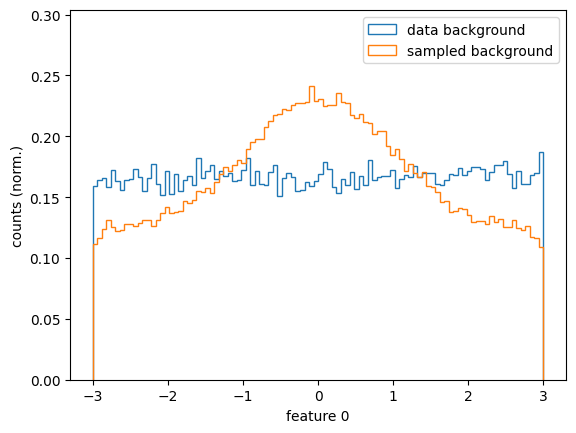

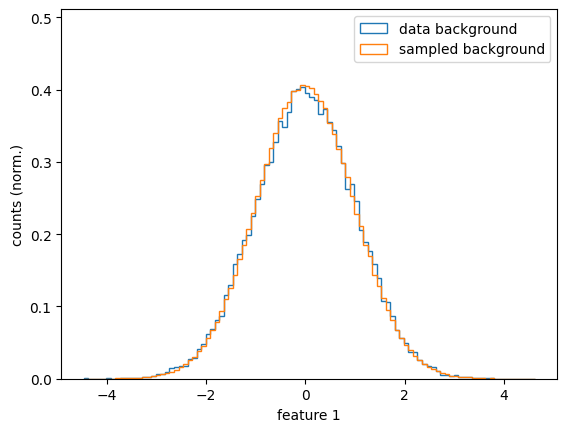

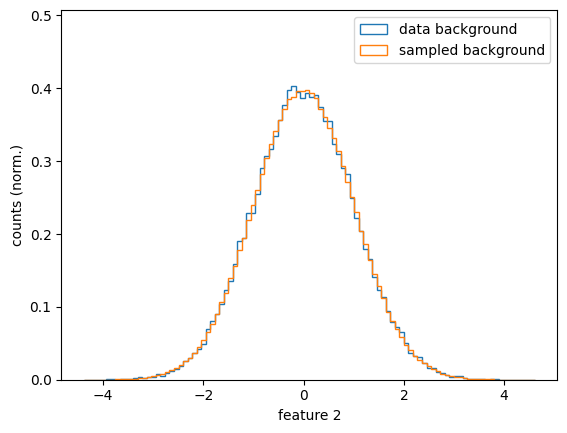

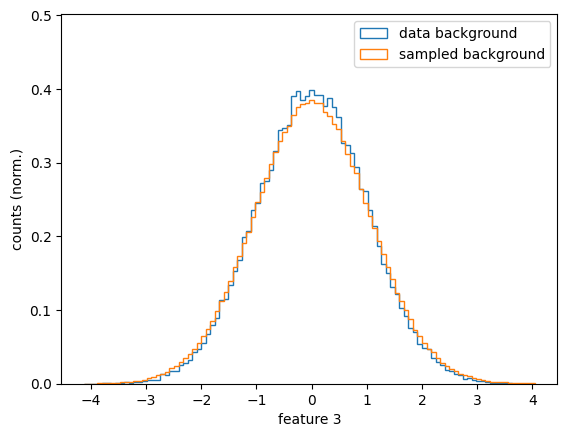

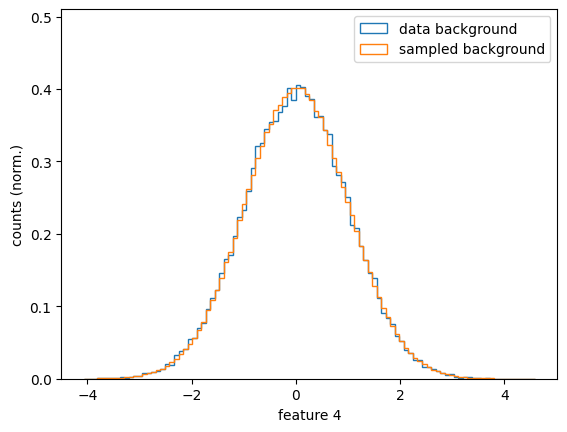

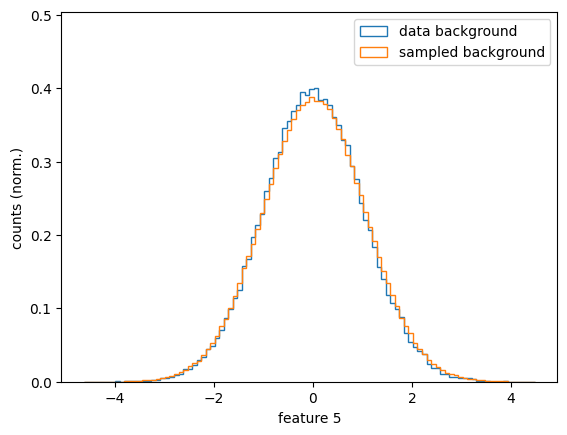

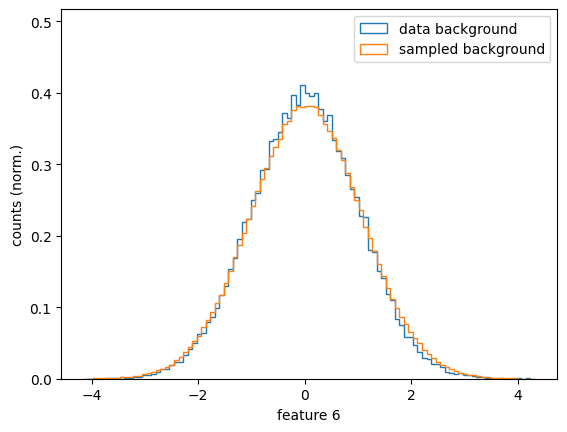

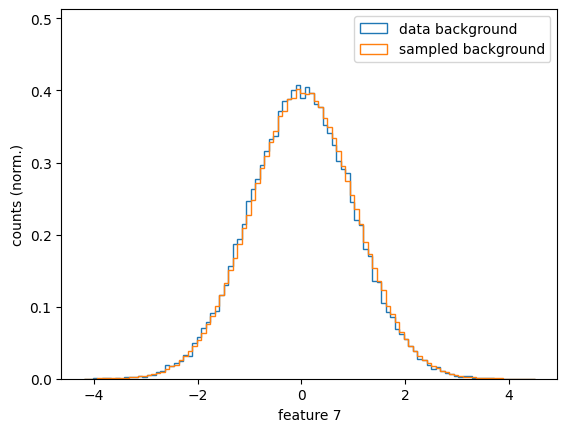

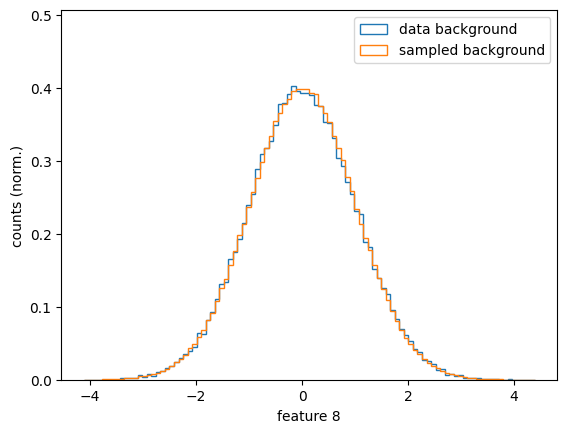

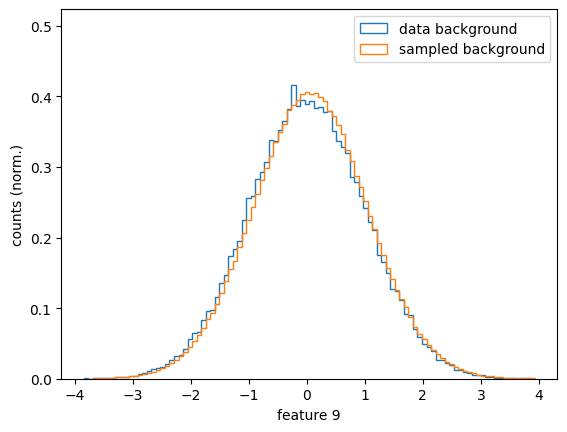

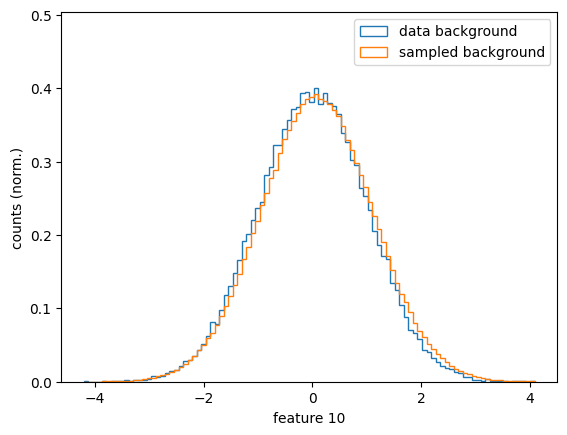

In [10]:
# comparing samples to inner background (idealized sanity check)

for i in range(cathode_samples_df.shape[1]):
    _, binning, _ = plt.hist(test_df[(test_df["signal"] == 0) & (test_df["SR"] == 1)].iloc[:, i],
                             bins=100, label="data background",
                             density=True, histtype="step")
    _ = plt.hist(cathode_samples_df.iloc[:, i],
                 bins=binning, label="sampled background",
                 density=True, histtype="step")
    plt.legend()
    plt.ylim(0, plt.gca().get_ylim()[1] * 1.2)
    plt.xlabel("feature {}".format(i))
    plt.ylabel("counts (norm.)")
    plt.show()

# Plot 2b
# Histogram of Latent Sampled Data (flow model) vs Latent True background data (standard normal)

This plot is used as a sense check to gauge how well the normalizing flow model has estimated the background distribution for the latent data

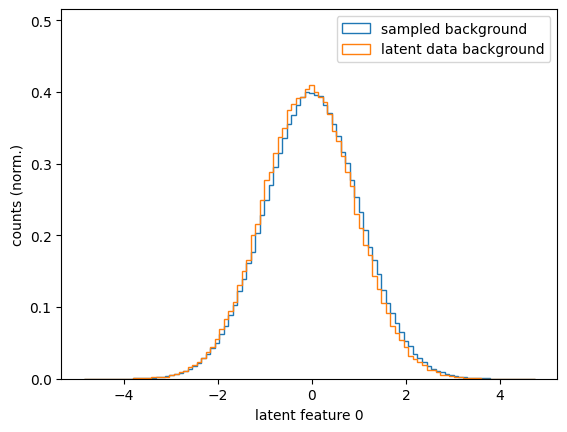

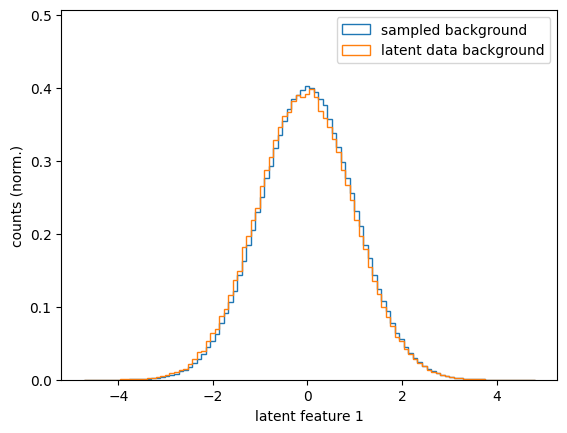

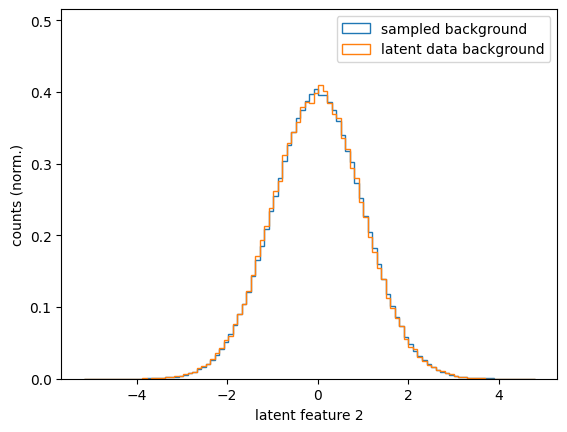

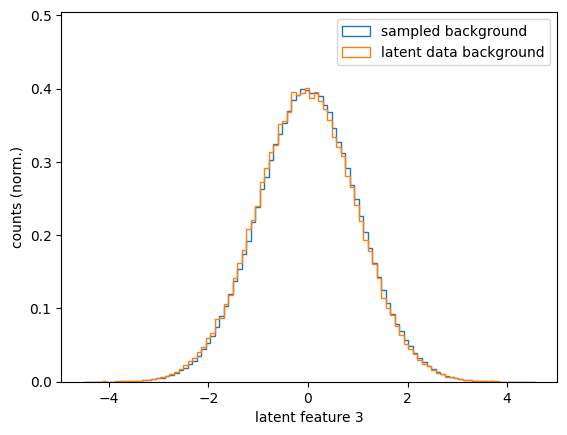

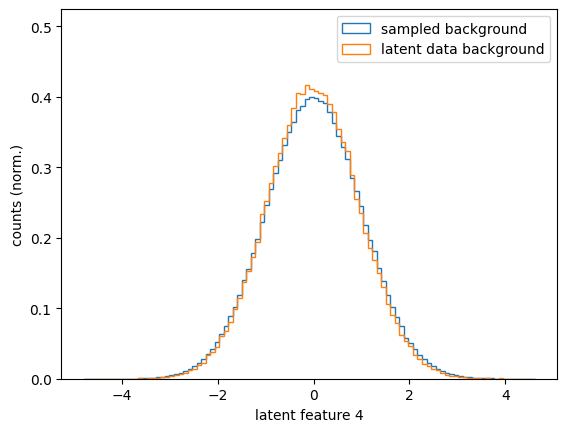

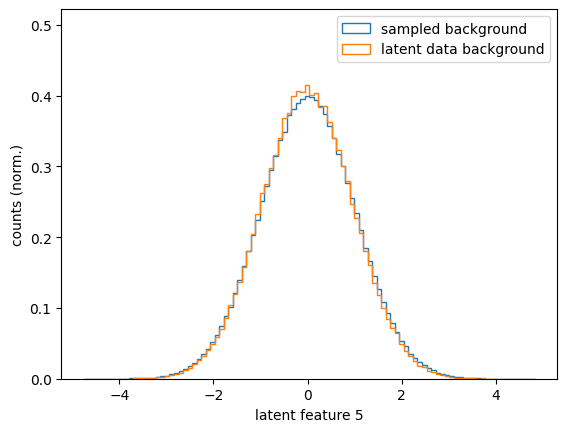

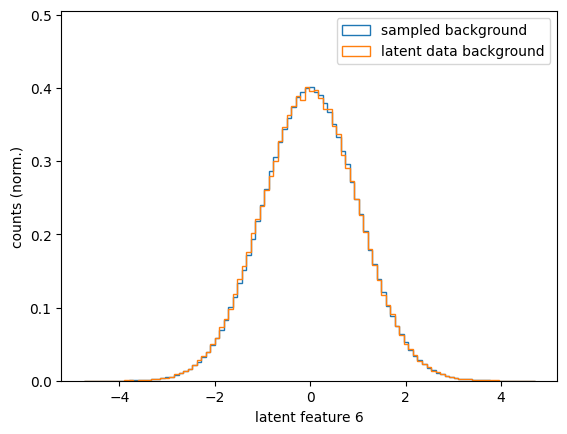

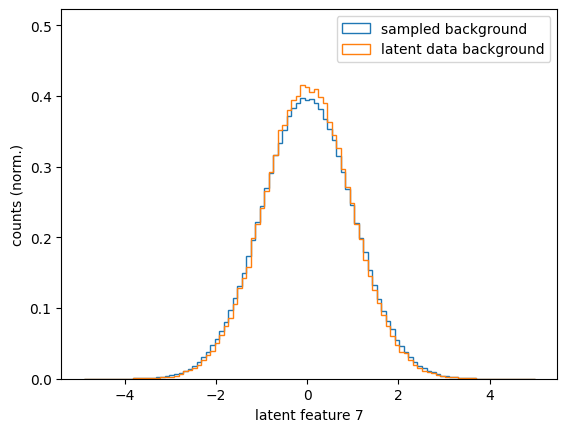

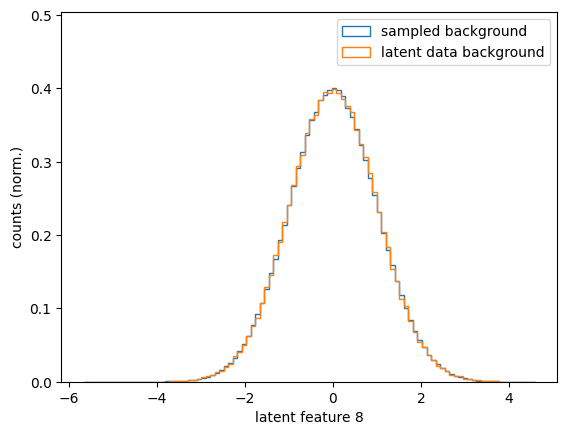

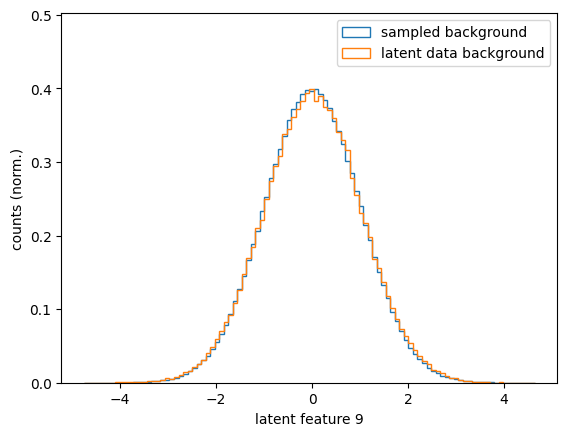

In [11]:
# Distribution for latent data check

# comparing samples to inner background (idealized sanity check)

for i in range(latent_sample_df.shape[1]):
    _, binning, _ = plt.hist(latent_sample_df.iloc[:,i],
                             bins=100, label="sampled background",
                             density=True, histtype="step")
    _ = plt.hist(latent_train_df[train_df[train_df["SR"] == 1].reset_index(drop = True)["signal"] == 0].iloc[:, i],
                 bins=binning, label="latent data background",
                 density=True, histtype="step")
    plt.legend()
    plt.ylim(0, plt.gca().get_ylim()[1] * 1.2)
    plt.xlabel("latent feature {}".format(i))
    plt.ylabel("counts (norm.)")
    plt.show()

# Plot 3
# Histogram of invariant mass distribution ($m_s$ & $m_b$) after applying cut (Before CDOT)

This plot is used to check for sculpting in the distribution after applying the cut.
The cut will be applied using a range of thresholds [50, 60, 70, 80, 90, 99]


In [12]:
# percentiles = [50, 60, 70, 80, 90, 99]

# for percentile in percentiles:
#     threshold = np.percentile(test_df["h"], percentile)
#     cutdata = test_df[test_df["h"] > threshold]

#     _, binning, _ = plt.hist(test_df[test_df["signal"]==0]["m"], bins = 100, label = "full data", histtype = "step", density = True)
#     _ = plt.hist(cutdata[cutdata["signal"]==0]["m"], bins = binning, label = "background data", histtype = "step", density = True)
#     _ = plt.hist(cutdata[cutdata["signal"]==1]["m"], bins = binning, label = "signal data", histtype = "step", density = True)
#     plt.xlabel("conditional feature")
#     plt.ylabel("counts")
#     plt.yscale("log")
#     plt.legend(loc="upper right")
#     plt.title(f"{percentile}th percentile cut")
#     plt.show()


In [13]:
# percentiles = [50, 60, 70, 80, 90, 99]

# for percentile in percentiles:
#     threshold = np.percentile(test_df["h"], percentile)
#     cutdata = test_df[test_df["h"] > threshold]

#     fig, axs = plt.subplots(1, 2, figsize=(10, 4))

#     for ax, density_flag, title_suffix in zip(
#         axs,
#         [True, False],
#         ["density=True", "density=False"]
#     ):
#         _, binning, _ = ax.hist(
#             test_df[test_df["signal"] == 0]["m"],
#             bins=100,
#             label="full data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.hist(
#             cutdata[cutdata["signal"] == 0]["m"],
#             bins=binning,
#             label="background data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.hist(
#             cutdata[cutdata["signal"] == 1]["m"],
#             bins=binning,
#             label="signal data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.set_xlabel("conditional feature")

#         # Log Scale for y-axis
#         # ax.set_yscale("log")                              
#         ax.set_title(title_suffix)

#     axs[0].set_ylabel("counts")
#     axs[0].legend(loc="upper right")

#     axs[1].set_ylabel("density")

#     fig.suptitle(f"{percentile}th percentile cut")
#     plt.tight_layout()
#     plt.show()


###  Classifier Outputs (Pre-CDOT) density plots (top) and histograms (bottom) of the invariant mass 

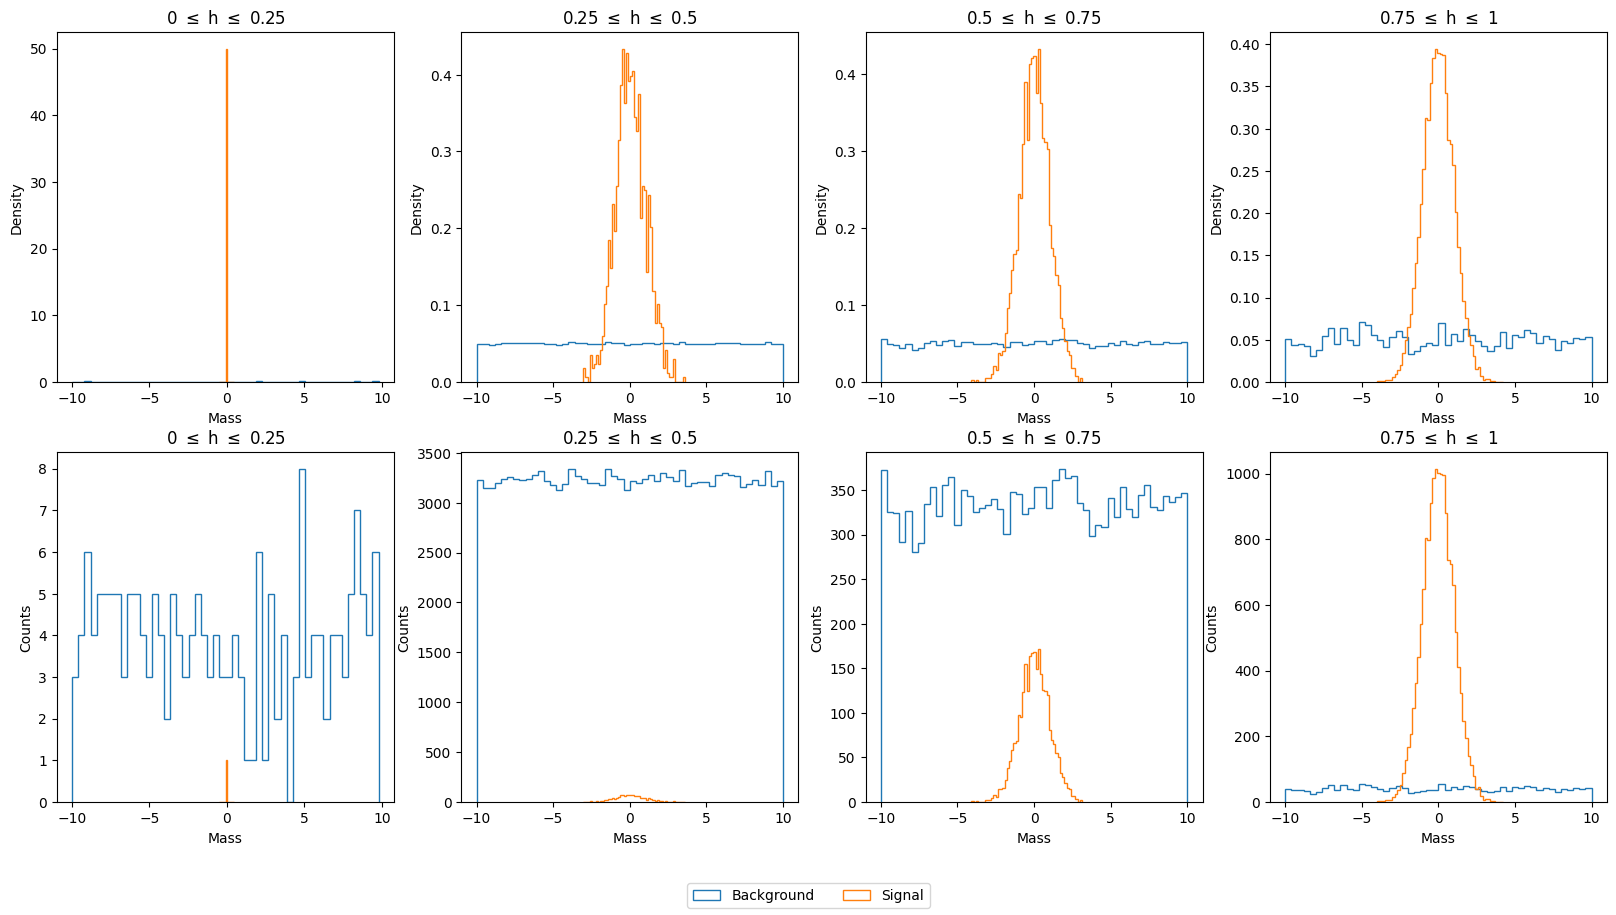

In [14]:
# Assign which classifier output you want to use
h = "h"     # Pre-CDOT classifier output

fig, axs = plt.subplots(2, 4, figsize = (20,10))

ranges = (0, 0.25, 0.5, 0.75, 1)

density_flag = (True, False)

y_label = ["Density", "Counts"]

for i in range(axs.shape[0]):
    # Assign the plot to be a density plot or a histogram
    density = density_flag[i]
    for j in range(axs.shape[1]):

        # Set the range of classifier outputs accepted for the plot
        lower_thresh = ranges[j]
        upper_thresh = ranges[j+1]

        cutdata = test_df[(test_df[h] >= lower_thresh) & (test_df[h] <= upper_thresh)]

        axs[i,j].hist(
            cutdata[cutdata["signal"] == 0]["m"],
            bins = 50,
            label = "Background",
            histtype = "step",
            density = density)
        
        axs[i,j].hist(
            cutdata[cutdata["signal"] == 1]["m"],
            bins = 50,
            label = "Signal",
            histtype = "step",
            density = density)
        
        axs[i,j].set_ylabel(y_label[i])
        axs[i,j].set_xlabel("Mass")
        axs[i,j].set_title(f"{lower_thresh} $\leq$ h $\leq$ {upper_thresh}")

h, l = axs[0,0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2)

plt.show()


# Plot 4
# Histogram of invariant mass distribution ($m_s$ & $m_b$) after applying cut (After CDOT)

This plot is used to check for sculpting in the distribution after applying the cut.
The cut will be applied using a range of thresholds [50, 60, 70, 80, 90, 99]


In [15]:
# percentiles = [50, 60, 70, 80, 90, 99]

# for percentile in percentiles:
#     threshold = np.percentile(test_df["trans_h"], percentile)
#     cutdata = test_df[test_df["trans_h"] > threshold]

#     fig, axs = plt.subplots(1, 2, figsize=(10, 4))

#     for ax, density_flag, title_suffix in zip(
#         axs,
#         [True, False],
#         ["density=True", "density=False"]
#     ):
#         _, binning, _ = ax.hist(
#             test_df[test_df["signal"] == 0]["m"],
#             bins=100,
#             label="full data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.hist(
#             cutdata[cutdata["signal"] == 0]["m"],
#             bins=binning,
#             label="background data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.hist(
#             cutdata[cutdata["signal"] == 1]["m"],
#             bins=binning,
#             label="signal data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.set_xlabel("conditional feature")

#         # Log Scale for y-axis
#         # ax.set_yscale("log")                              
#         ax.set_title(title_suffix)

#     axs[0].set_ylabel("counts")
#     axs[0].legend(loc="upper right")

#     axs[1].set_ylabel("density")

#     fig.suptitle(f"{percentile}th percentile cut")
#     plt.tight_layout()
#     plt.show()


### Applying the Cut using fixed values (opposed to percentiles)

In [16]:
# thresholds = [0.5, 0.6, 0.7, 0.8, 0.9, 0.99]

# for threshold in thresholds:
#     cutdata = test_df[test_df["trans_h"] > threshold]

#     fig, axs = plt.subplots(1, 2, figsize=(10, 4))

#     for ax, density_flag, title_suffix in zip(
#         axs,
#         [True, False],
#         ["density=True", "density=False"]
#     ):
#         _, binning, _ = ax.hist(
#             test_df[test_df["signal"] == 0]["m"],
#             bins=100,
#             label="full data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.hist(
#             cutdata[cutdata["signal"] == 0]["m"],
#             bins=binning,
#             label="background data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.hist(
#             cutdata[cutdata["signal"] == 1]["m"],
#             bins=binning,
#             label="signal data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.set_xlabel("conditional feature")

#         # Log Scale for y-axis
#         # ax.set_yscale("log")                              
#         ax.set_title(title_suffix)

#     axs[0].set_ylabel("counts")
#     axs[0].legend(loc="upper right")

#     axs[1].set_ylabel("density")

#     fig.suptitle(f"Cut Threshold = {threshold}")
#     plt.tight_layout()
#     plt.show()


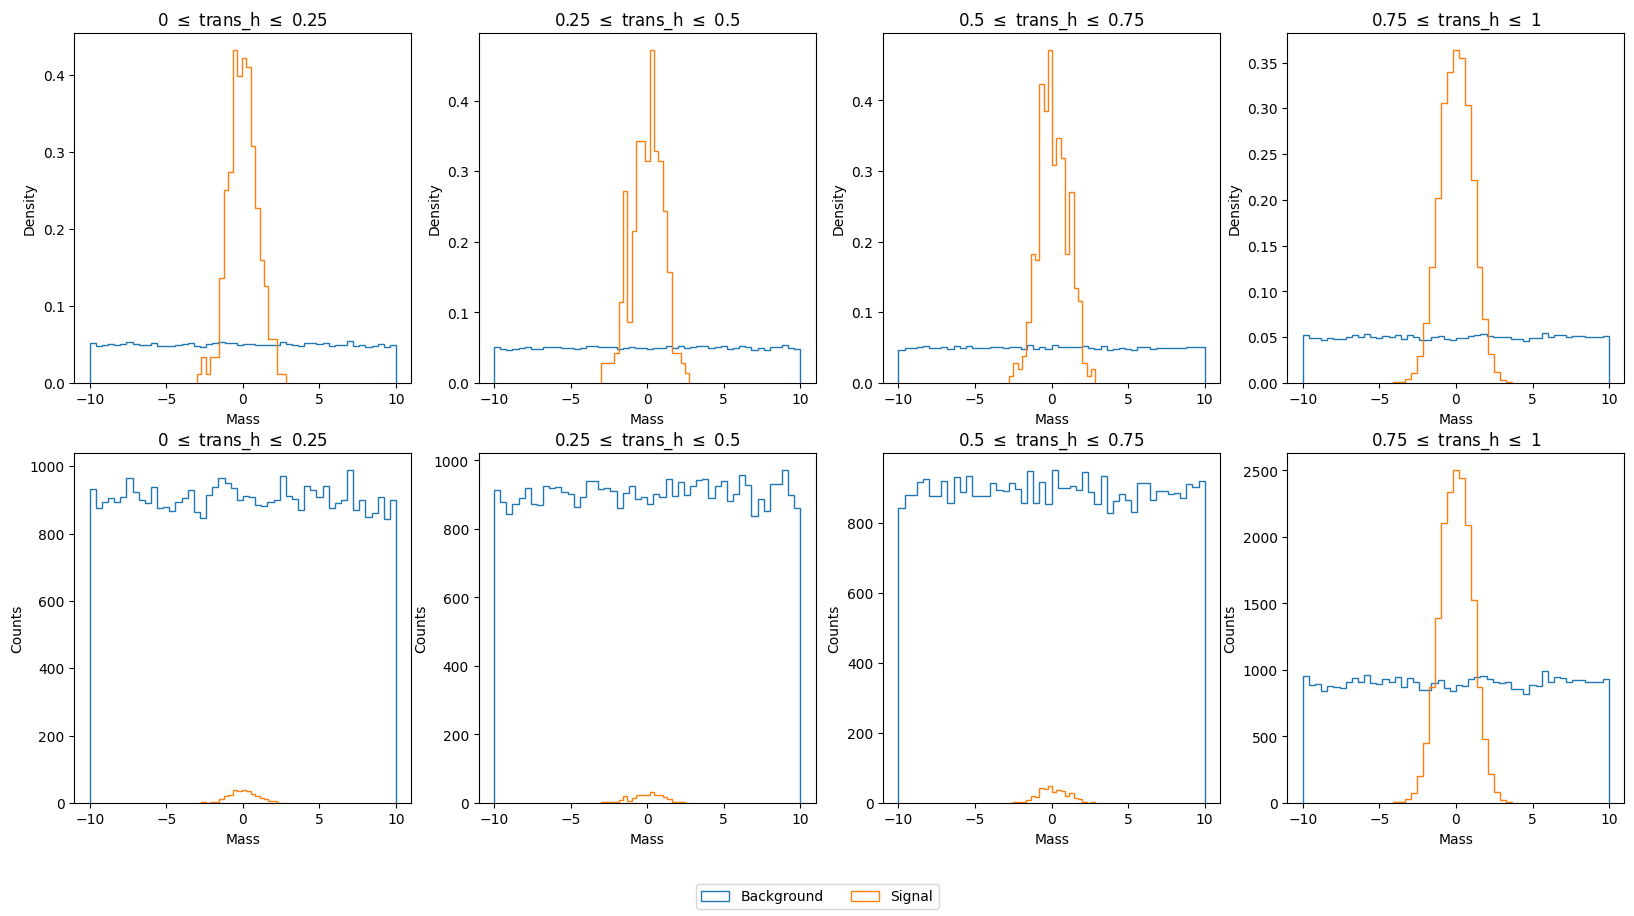

In [17]:
# Assign which classifier output you want to use
h = "trans_h"     # Pre-CDOT classifier output

fig, axs = plt.subplots(2, 4, figsize = (20,10))

ranges = (0, 0.25, 0.5, 0.75, 1)

density_flag = (True, False)

y_label = ["Density", "Counts"]

for i in range(axs.shape[0]):
    # Assign the plot to be a density plot or a histogram
    density = density_flag[i]
    for j in range(axs.shape[1]):

        # Set the range of classifier outputs accepted for the plot
        lower_thresh = ranges[j]
        upper_thresh = ranges[j+1]

        cutdata = test_df[(test_df[h] >= lower_thresh) & (test_df[h] <= upper_thresh)]

        axs[i,j].hist(
            cutdata[cutdata["signal"] == 0]["m"],
            bins = 50,
            label = "Background",
            histtype = "step",
            density = density)
        
        axs[i,j].hist(
            cutdata[cutdata["signal"] == 1]["m"],
            bins = 20,
            label = "Signal",
            histtype = "step",
            density = density)
        
        axs[i,j].set_ylabel(y_label[i])
        axs[i,j].set_xlabel("Mass")
        axs[i,j].set_title(f"{lower_thresh} $\leq$ trans_h $\leq$ {upper_thresh}")

h, l = axs[0,0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2)

plt.show()


# Plot 4
# Histogram of invariant mass distribution ($m_s$ & $m_b$) after applying cut (After CDOT)

This plot is used to check for sculpting in the distribution after applying the cut.
The cut will be applied using a range of thresholds [50, 60, 70, 80, 90, 99]


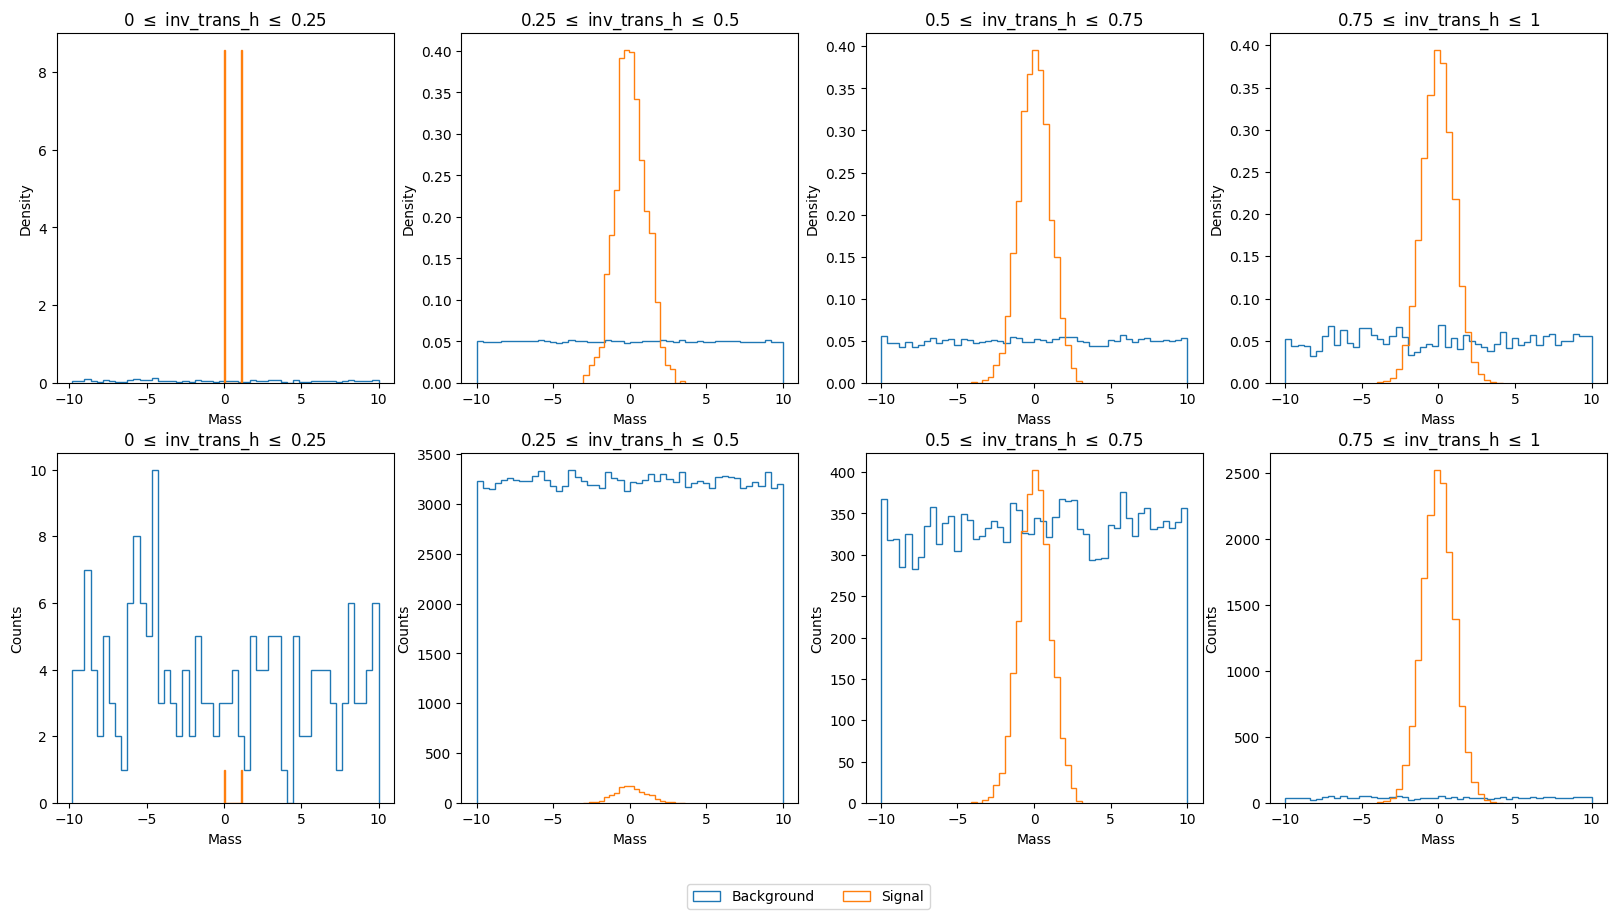

In [18]:
# Assign which classifier output you want to use
h = "inv_trans_h"     # Pre-CDOT classifier output

fig, axs = plt.subplots(2, 4, figsize = (20,10))

ranges = (0, 0.25, 0.5, 0.75, 1)

density_flag = (True, False)

y_label = ["Density", "Counts"]

for i in range(axs.shape[0]):
    # Assign the plot to be a density plot or a histogram
    density = density_flag[i]
    for j in range(axs.shape[1]):

        # Set the range of classifier outputs accepted for the plot
        lower_thresh = ranges[j]
        upper_thresh = ranges[j+1]

        cutdata = test_df[(test_df[h] >= lower_thresh) & (test_df[h] <= upper_thresh)]

        axs[i,j].hist(
            cutdata[cutdata["signal"] == 0]["m"],
            bins = 50,
            label = "Background",
            histtype = "step",
            density = density)
        
        axs[i,j].hist(
            cutdata[cutdata["signal"] == 1]["m"],
            bins = 20,
            label = "Signal",
            histtype = "step",
            density = density)
        
        axs[i,j].set_ylabel(y_label[i])
        axs[i,j].set_xlabel("Mass")
        axs[i,j].set_title(f"{lower_thresh} $\leq$ {h} $\leq$ {upper_thresh}")

h, l = axs[0,0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2)

plt.show()


# Plot 5
# Histogram of invariant mass distribution ($m_s$ & $m_b$) after applying cut (LaCATHODE)

This plot is used to check for sculpting in the distribution after applying the cut.
The cut will be applied using a range of thresholds [50, 60, 70, 80, 90, 99]


In [19]:
# percentiles = [50, 60, 70, 80, 90, 99]

# for percentile in percentiles:
#     threshold = np.percentile(test_df[~np.isnan(test_df["la_h"])]["la_h"], percentile) 
#     cutdata = test_df[test_df["la_h"] > threshold]

#     fig, axs = plt.subplots(1, 2, figsize=(10, 4))

#     for ax, density_flag, title_suffix in zip(
#         axs,
#         [True, False],
#         ["density=True", "density=False"]
#     ):
#         _, binning, _ = ax.hist(
#             test_df[test_df["signal"] == 0]["m"],
#             bins=100,
#             label="full data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.hist(
#             cutdata[cutdata["signal"] == 0]["m"],
#             bins=binning,
#             label="background data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.hist(
#             cutdata[cutdata["signal"] == 1]["m"],
#             bins=binning,
#             label="signal data",
#             histtype="step",
#             density=density_flag,
#         )

#         ax.set_xlabel("conditional feature")

#         # Log Scale for y-axis
#         # ax.set_yscale("log")                              
#         ax.set_title(title_suffix)

#     axs[0].set_ylabel("counts")
#     axs[0].legend(loc="upper right")

#     axs[1].set_ylabel("density")

#     fig.suptitle(f"{percentile}th percentile cut")
#     plt.tight_layout()
#     plt.show()


/Users/hamzashah/anaconda3/envs/sk_cathode_env/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


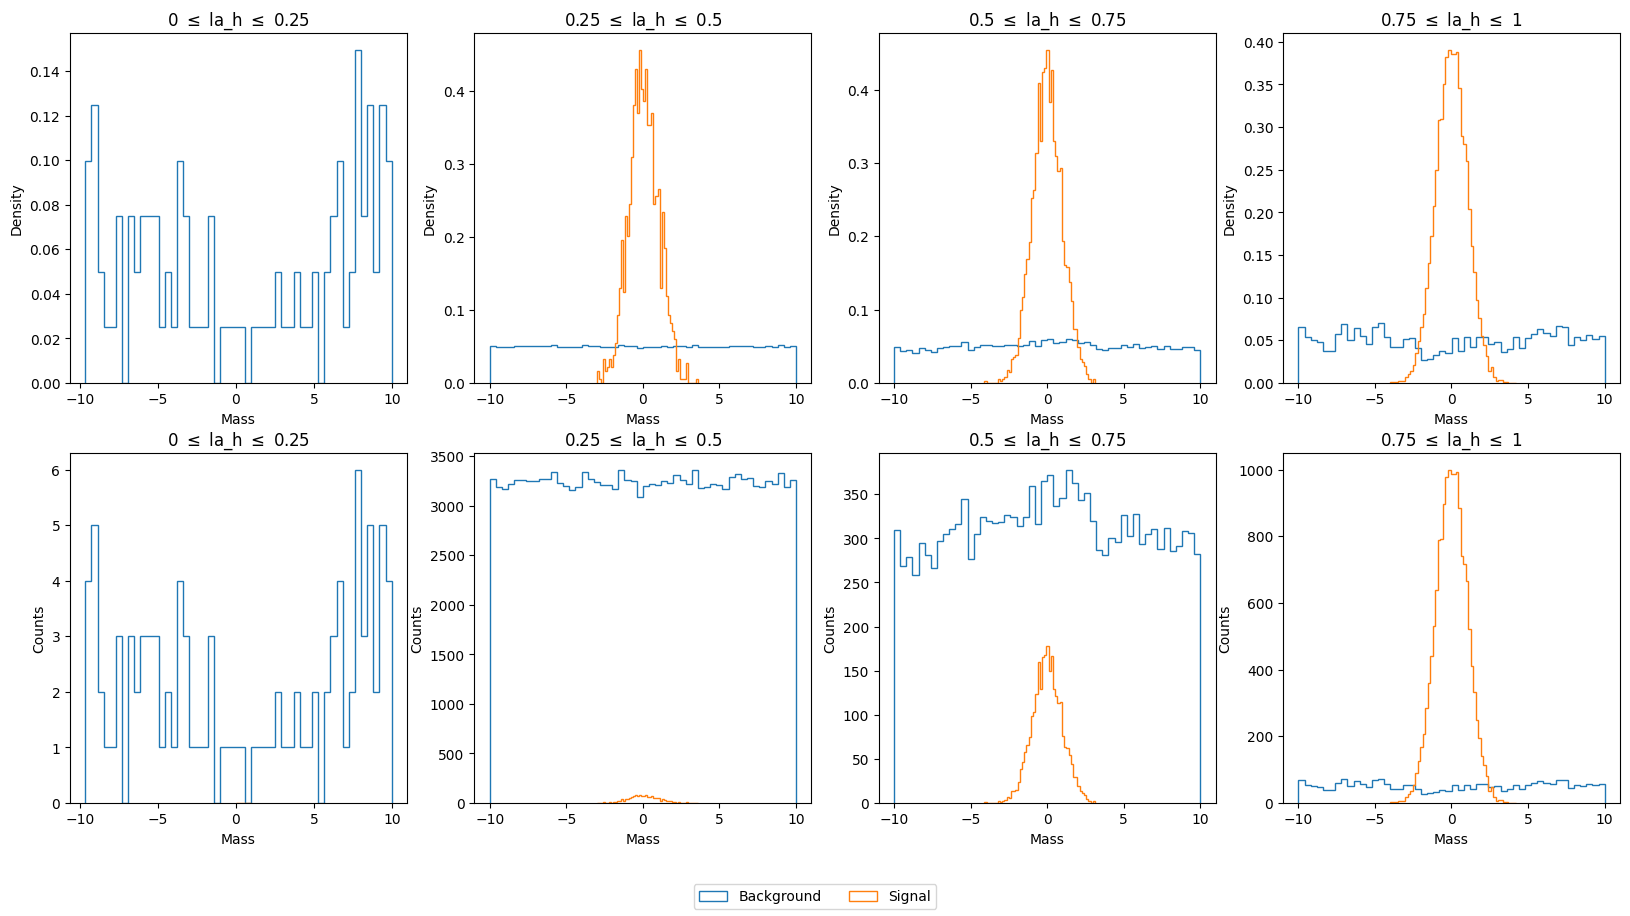

In [20]:
# Assign which classifier output you want to use
h = "la_h"     # LaCATHODE classifier output

fig, axs = plt.subplots(2, 4, figsize = (20,10))

ranges = (0, 0.25, 0.5, 0.75, 1)

density_flag = (True, False)

y_label = ["Density", "Counts"]

for i in range(axs.shape[0]):
    # Assign the plot to be a density plot or a histogram
    density = density_flag[i]
    for j in range(axs.shape[1]):

        # Set the range of classifier outputs accepted for the plot
        lower_thresh = ranges[j]
        upper_thresh = ranges[j+1]

        cutdata = test_df[(test_df[h] >= lower_thresh) & (test_df[h] <= upper_thresh)]

        axs[i,j].hist(
            cutdata[cutdata["signal"] == 0]["m"],
            bins = 50,
            label = "Background",
            histtype = "step",
            density = density)
        
        axs[i,j].hist(
            cutdata[cutdata["signal"] == 1]["m"],
            bins = 50,
            label = "Signal",
            histtype = "step",
            density = density)
        
        axs[i,j].set_ylabel(y_label[i])
        axs[i,j].set_xlabel("Mass")
        axs[i,j].set_title(f"{lower_thresh} $\leq$ {h} $\leq$ {upper_thresh}")

h, l = axs[0,0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2)

plt.show()


# Plot 5b
# Histogram of invariant mass distribution ($m_s$ & $m_b$) after applying cut (Idealised Classifier Pre-CDOT)



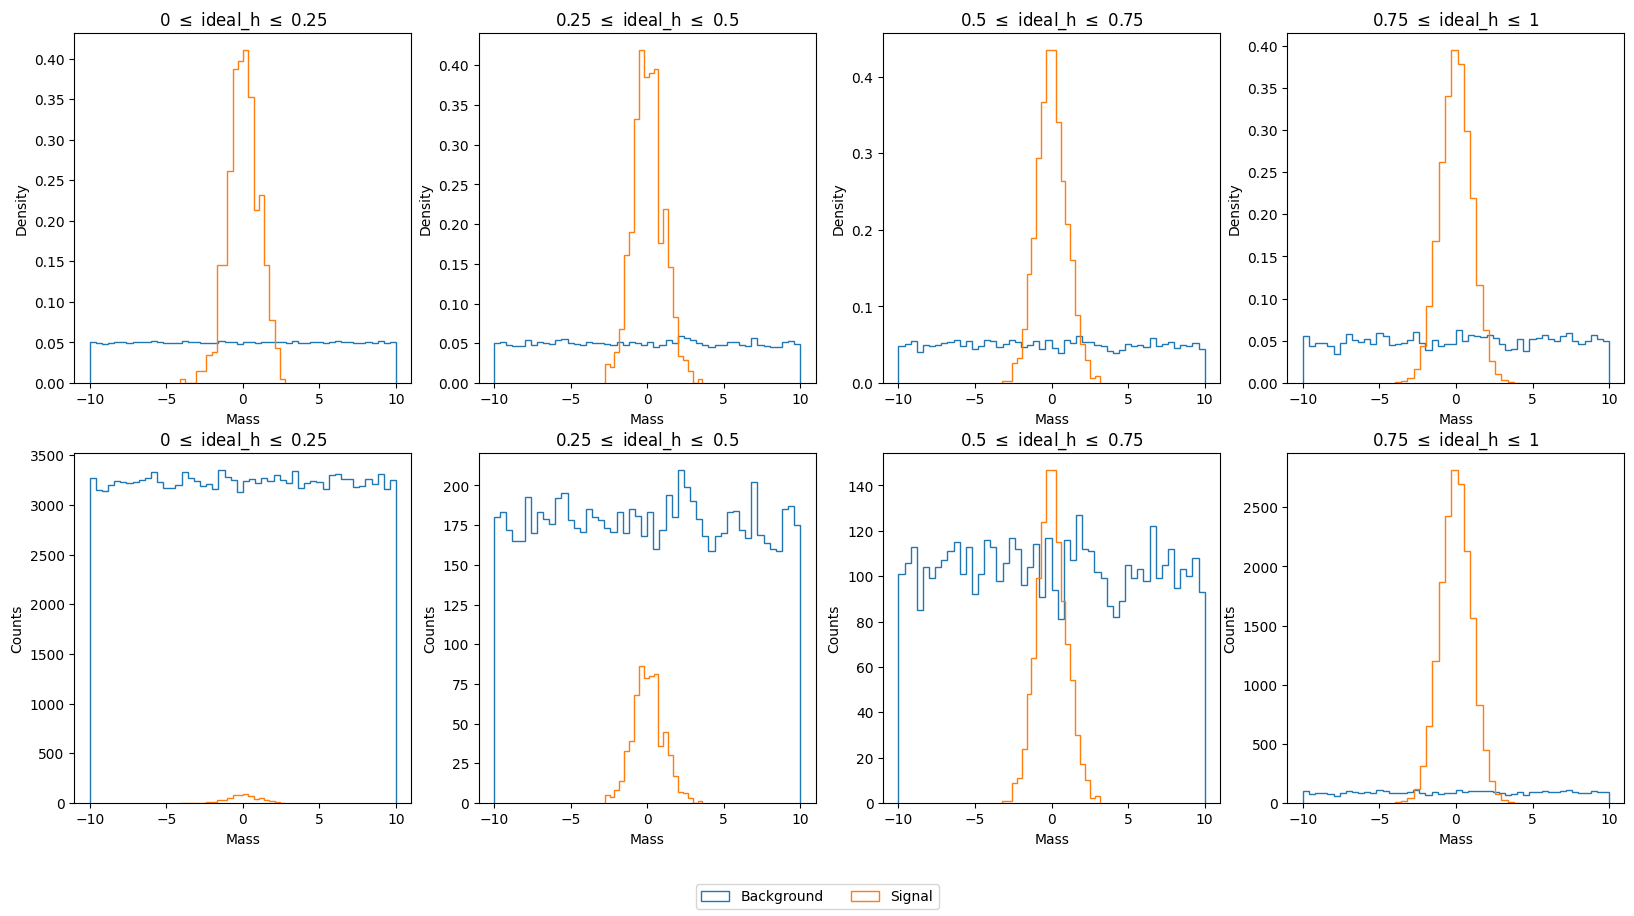

In [21]:
# Assign which classifier output you want to use
h = "ideal_h"     # Pre-CDOT classifier output

fig, axs = plt.subplots(2, 4, figsize = (20,10), sharex = True)

ranges = (0, 0.25, 0.5, 0.75, 1)

density_flag = (True, False)

y_label = ["Density", "Counts"]

for i in range(axs.shape[0]):
    # Assign the plot to be a density plot or a histogram
    density = density_flag[i]
    for j in range(axs.shape[1]):
        axs[i,j].tick_params(axis = "x", labelbottom = True)
        # Set the range of classifier outputs accepted for the plot
        lower_thresh = ranges[j]
        upper_thresh = ranges[j+1]

        cutdata = test_df[(test_df[h] >= lower_thresh) & (test_df[h] <= upper_thresh)]

        axs[i,j].hist(
            cutdata[cutdata["signal"] == 0]["m"],
            bins = 50,
            label = "Background",
            histtype = "step",
            density = density)
        
        axs[i,j].hist(
            cutdata[cutdata["signal"] == 1]["m"],
            bins = 20,
            label = "Signal",
            histtype = "step",
            density = density)
        
        axs[i,j].set_ylabel(y_label[i])
        axs[i,j].set_xlabel("Mass")
        axs[i,j].set_title(f"{lower_thresh} $\leq$ {h} $\leq$ {upper_thresh}")

h, l = axs[0,0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2)

plt.show()


# Plot 5c
# Histogram of invariant mass distribution ($m_s$ & $m_b$) after applying cut (Idealised Classifier Post-CDOT)



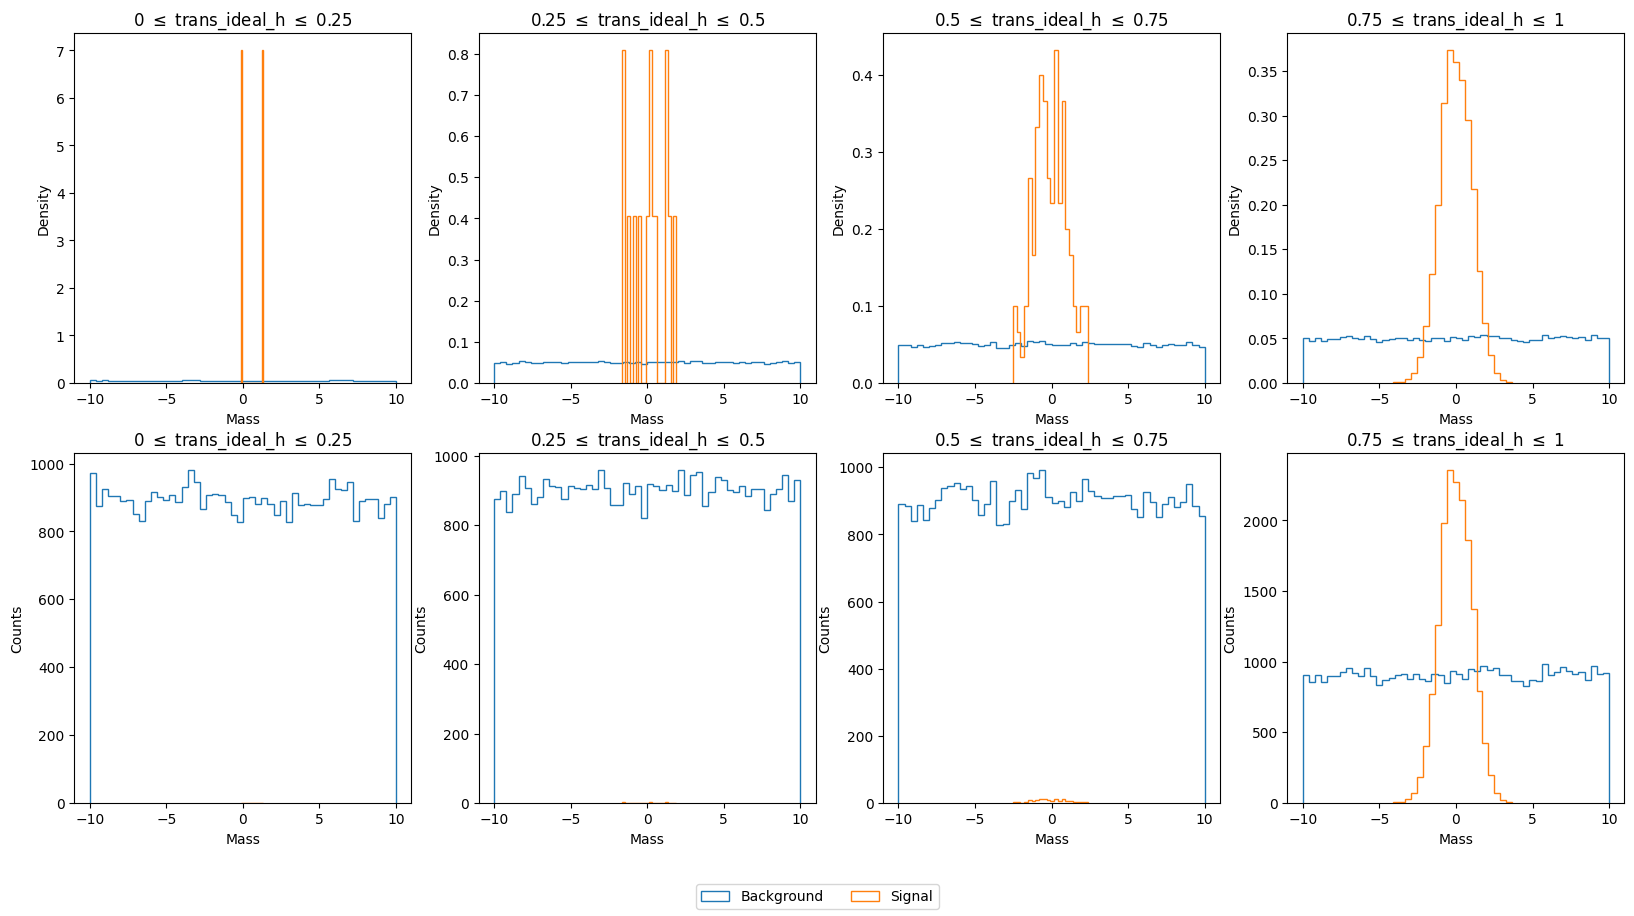

In [22]:
# Assign which classifier output you want to use
h = "trans_ideal_h"     # Pre-CDOT classifier output

fig, axs = plt.subplots(2, 4, figsize = (20,10), sharex = True)

ranges = (0, 0.25, 0.5, 0.75, 1)

density_flag = (True, False)

y_label = ["Density", "Counts"]

for i in range(axs.shape[0]):
    # Assign the plot to be a density plot or a histogram
    density = density_flag[i]
    for j in range(axs.shape[1]):
        axs[i,j].tick_params(axis = "x", labelbottom = True)
        # Set the range of classifier outputs accepted for the plot
        lower_thresh = ranges[j]
        upper_thresh = ranges[j+1]

        cutdata = test_df[(test_df[h] >= lower_thresh) & (test_df[h] <= upper_thresh)]

        axs[i,j].hist(
            cutdata[cutdata["signal"] == 0]["m"],
            bins = 50,
            label = "Background",
            histtype = "step",
            density = density)
        
        axs[i,j].hist(
            cutdata[cutdata["signal"] == 1]["m"],
            bins = 20,
            label = "Signal",
            histtype = "step",
            density = density)
        
        axs[i,j].set_ylabel(y_label[i])
        axs[i,j].set_xlabel("Mass")
        axs[i,j].set_title(f"{lower_thresh} $\leq$ {h} $\leq$ {upper_thresh}")

h, l = axs[0,0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2)

plt.show()


# Plot 5d
# Histogram of invariant mass distribution ($m_s$ & $m_b$) after applying cut (Idealised Classifier Post-Inverse CDOT)



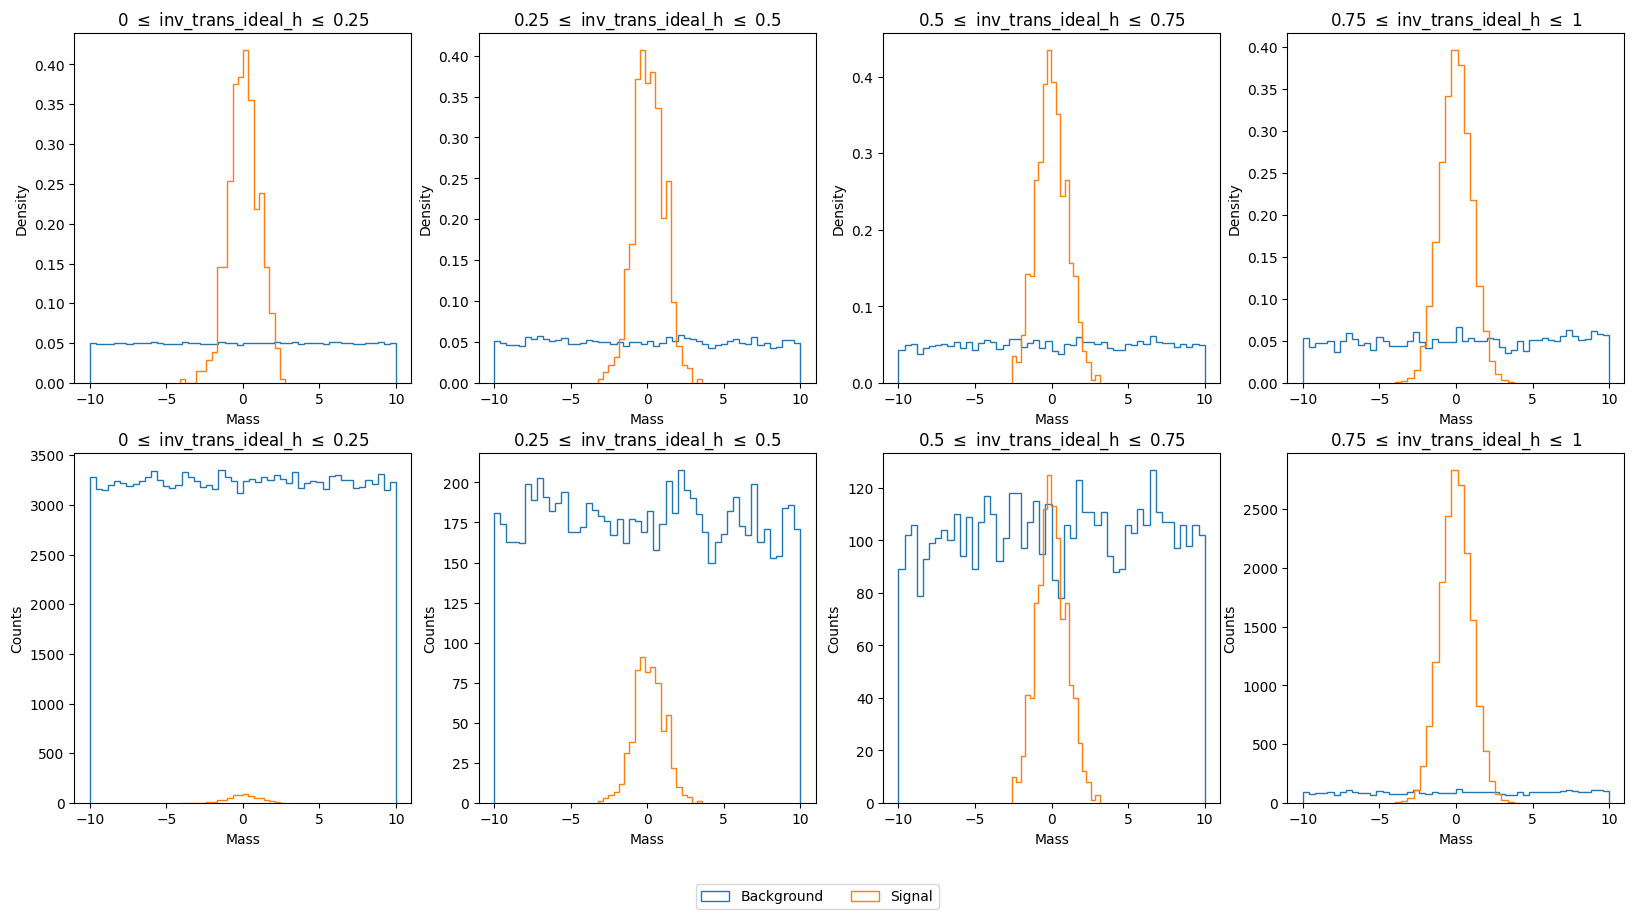

In [23]:
# Assign which classifier output you want to use
h = "inv_trans_ideal_h"     # Pre-CDOT classifier output

fig, axs = plt.subplots(2, 4, figsize = (20,10), sharex = True)

ranges = (0, 0.25, 0.5, 0.75, 1)

density_flag = (True, False)

y_label = ["Density", "Counts"]

for i in range(axs.shape[0]):
    # Assign the plot to be a density plot or a histogram
    density = density_flag[i]
    for j in range(axs.shape[1]):
        axs[i,j].tick_params(axis = "x", labelbottom = True)
        # Set the range of classifier outputs accepted for the plot
        lower_thresh = ranges[j]
        upper_thresh = ranges[j+1]

        cutdata = test_df[(test_df[h] >= lower_thresh) & (test_df[h] <= upper_thresh)]

        axs[i,j].hist(
            cutdata[cutdata["signal"] == 0]["m"],
            bins = 50,
            label = "Background",
            histtype = "step",
            density = density)
        
        axs[i,j].hist(
            cutdata[cutdata["signal"] == 1]["m"],
            bins = 20,
            label = "Signal",
            histtype = "step",
            density = density)
        
        axs[i,j].set_ylabel(y_label[i])
        axs[i,j].set_xlabel("Mass")
        axs[i,j].set_title(f"{lower_thresh} $\leq$ {h} $\leq$ {upper_thresh}")

h, l = axs[0,0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2)

plt.show()


# Plot 6
# Classifier Output (Before and After CDOT)

This plot produces the distribution of the transformed classifier output to check for uniformity.

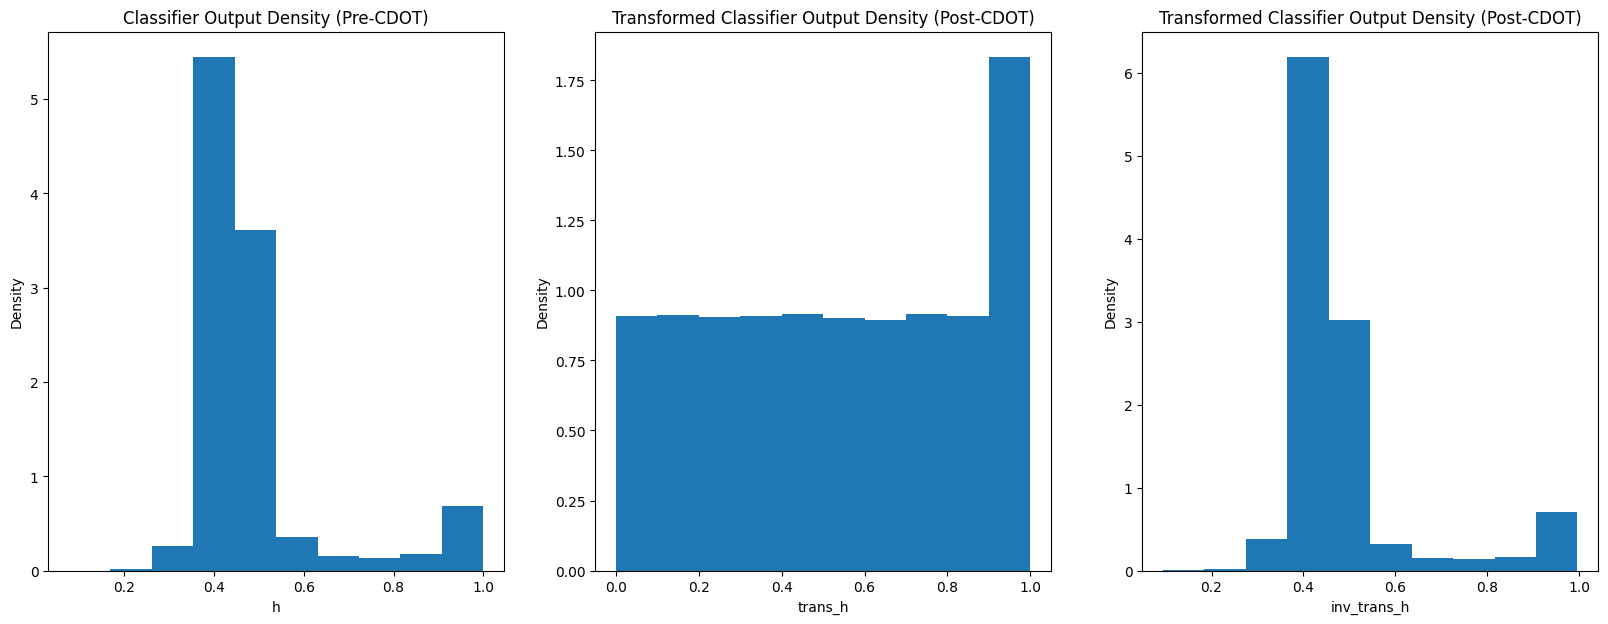

In [24]:
fig, axs = plt.subplots(1,3, figsize = (20,7))


axs[0].hist(test_df["h"], density=True)
axs[0].set_xlabel("h")
axs[0].set_ylabel("Density")
axs[0].set_title("Classifier Output Density (Pre-CDOT)")

axs[1].hist(test_df["trans_h"], density=True)
axs[1].set_xlabel("trans_h")
axs[1].set_ylabel("Density")
axs[1].set_title("Transformed Classifier Output Density (Post-CDOT)")

axs[2].hist(test_df["inv_trans_h"], density=True)
axs[2].set_xlabel("inv_trans_h")
axs[2].set_ylabel("Density")
axs[2].set_title("Transformed Classifier Output Density (Post-CDOT)")

plt.show()

# Plot 6b
# Idealised Classifier Output (Before and After CDOT)

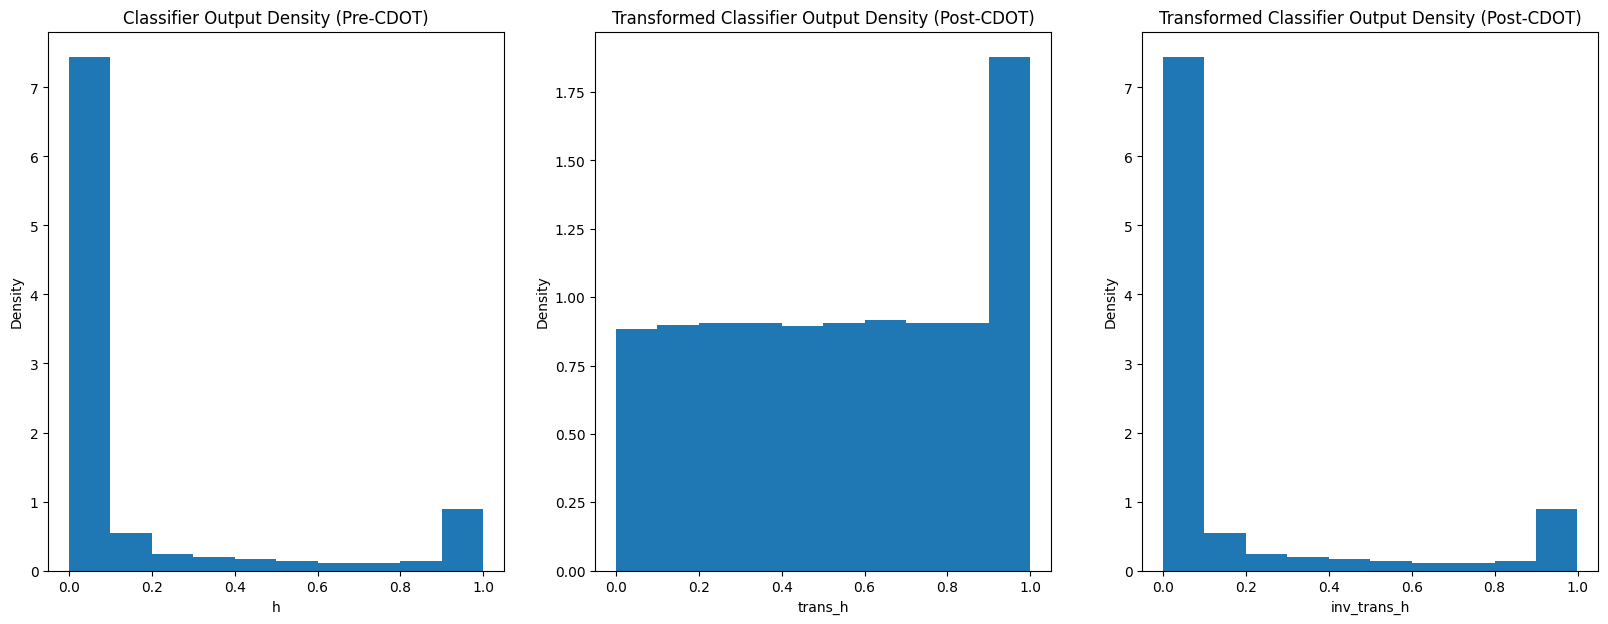

In [25]:
fig, axs = plt.subplots(1,3, figsize = (20,7))


axs[0].hist(test_df["ideal_h"], density=True)
axs[0].set_xlabel("h")
axs[0].set_ylabel("Density")
axs[0].set_title("Classifier Output Density (Pre-CDOT)")

axs[1].hist(test_df["trans_ideal_h"], density=True)
axs[1].set_xlabel("trans_h")
axs[1].set_ylabel("Density")
axs[1].set_title("Transformed Classifier Output Density (Post-CDOT)")

axs[2].hist(test_df["inv_trans_ideal_h"], density=True)
axs[2].set_xlabel("inv_trans_h")
axs[2].set_ylabel("Density")
axs[2].set_title("Transformed Classifier Output Density (Post-CDOT)")

plt.show()

# Plot 6c
# (CATHODE) Classifier vs Transformed Classifier Ouputs

x-axis: (Pre-CDOT) Classifier Outputs
y-axis: (Post-CDOT) Transformed Classifier Outputs

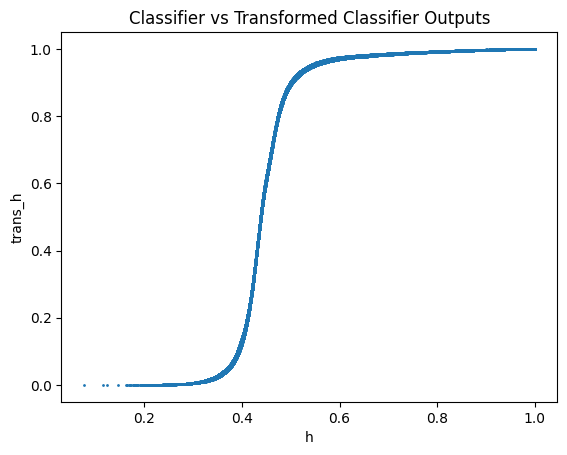

In [26]:
plt.scatter(x = test_df["h"], y = test_df["trans_h"], s = 1)
plt.xlabel("h")
plt.ylabel("trans_h")
plt.title("Classifier vs Transformed Classifier Outputs")
plt.show()

# Plot 6d
# (Idealised) Classifier vs Transformed Classifier Ouputs

x-axis: (Pre-CDOT) Classifier Outputs 

y-axis: (Post-CDOT) Transformed Classifier Outputs

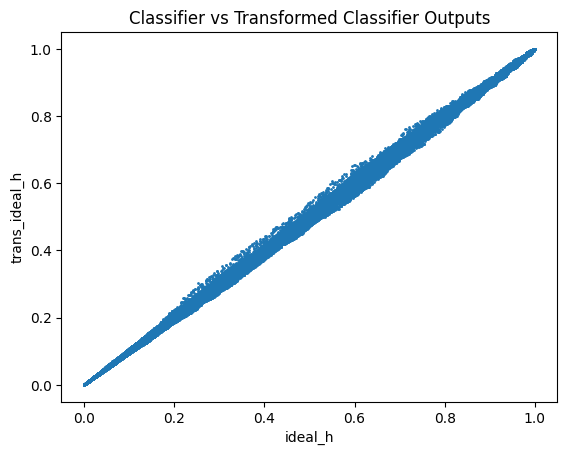

In [27]:
plt.scatter(x = test_df["ideal_h"], y = test_df["inv_trans_ideal_h"], s = 1)
plt.xlabel("ideal_h")
plt.ylabel("trans_ideal_h")
plt.title("Classifier vs Transformed Classifier Outputs")
plt.show()

# Plot 7 
# SIC curve (Comparing Classifiers)



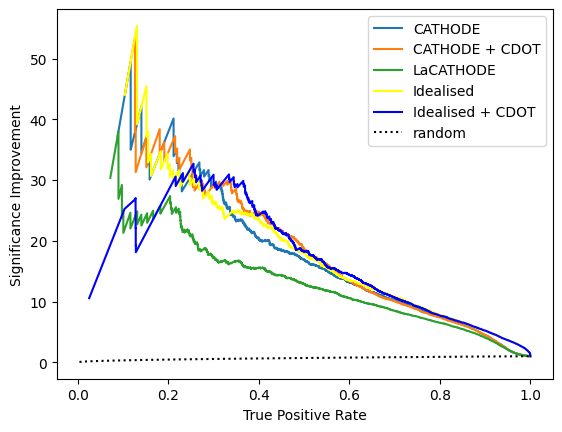

In [28]:

with np.errstate(divide='ignore', invalid='ignore'):
    # Classifier Outputs (Pre-CDOT)
    h_fpr, h_tpr, _ = roc_curve(test_df["signal"], test_df["h"])
    h_sic = h_tpr / np.sqrt(h_fpr)

    # Transformed Classifier outputs (Post-CDOT)
    trans_h_fpr, trans_h_tpr, _ = roc_curve(test_df["signal"], test_df["trans_h"])
    trans_h_sic = trans_h_tpr / np.sqrt(trans_h_fpr)

    # Inverse Transformed Classifier outputs (Post-CDOT)
    inv_trans_h_fpr, inv_trans_h_tpr, _ = roc_curve(test_df["signal"], test_df["inv_trans_h"])
    inv_trans_h_sic = inv_trans_h_tpr / np.sqrt(inv_trans_h_fpr)

    # LaCATHODE classifier outputs
    la_h_fpr, la_h_tpr, _ = roc_curve(test_df[~np.isnan(test_df["la_h"])]["signal"], test_df[~np.isnan(test_df["la_h"])]["la_h"])
    la_h_sic = la_h_tpr / np.sqrt(la_h_fpr)

    # Idealised Classifier Outputs (Pre-CDOT)
    ideal_h_fpr, ideal_h_tpr, _ = roc_curve(test_df["signal"], test_df["ideal_h"])
    ideal_h_sic = ideal_h_tpr / np.sqrt(ideal_h_fpr)

    # Idealised Classifier Outputs (Post-CDOT)
    trans_ideal_h_fpr, trans_ideal_h_tpr, _ = roc_curve(test_df["signal"], test_df["trans_ideal_h"])
    trans_ideal_h_sic = trans_ideal_h_tpr / np.sqrt(trans_ideal_h_fpr)

    # Random Line
    random_tpr = np.linspace(0, 1, 300)
    random_sic = random_tpr / np.sqrt(random_tpr)

plt.plot(h_tpr, h_sic, label="CATHODE")
plt.plot(trans_h_tpr, trans_h_sic, label="CATHODE + CDOT")
plt.plot(la_h_tpr, la_h_sic, label="LaCATHODE")
plt.plot(ideal_h_tpr, ideal_h_sic, label = "Idealised", color = "yellow")
plt.plot(trans_ideal_h_tpr, trans_ideal_h_sic, label = "Idealised + CDOT", color = "blue")
plt.plot(random_tpr, random_sic, "k:", label="random")
plt.xlabel("True Positive Rate")
plt.ylabel("Significance Improvement")
plt.legend(loc="upper right")
plt.show()

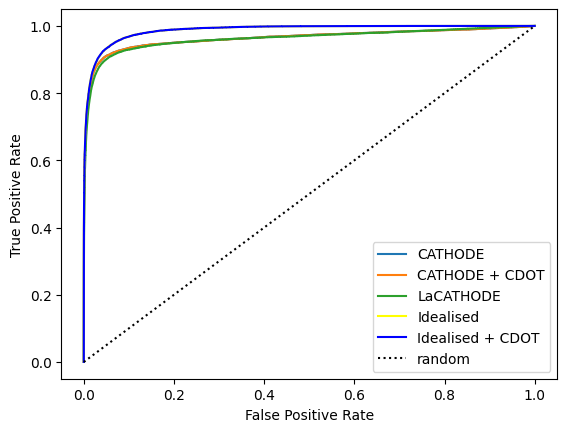

In [29]:
# ROC curve

plt.plot(h_fpr, h_tpr, label="CATHODE")
plt.plot(trans_h_fpr, trans_h_tpr, label="CATHODE + CDOT")
plt.plot(la_h_fpr, la_h_tpr, label="LaCATHODE")
plt.plot(ideal_h_fpr, ideal_h_tpr, label = "Idealised", color = "yellow")
plt.plot(trans_ideal_h_fpr, trans_ideal_h_tpr, label = "Idealised + CDOT", color = "blue")
plt.plot(random_tpr, random_tpr, "k:", label="random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

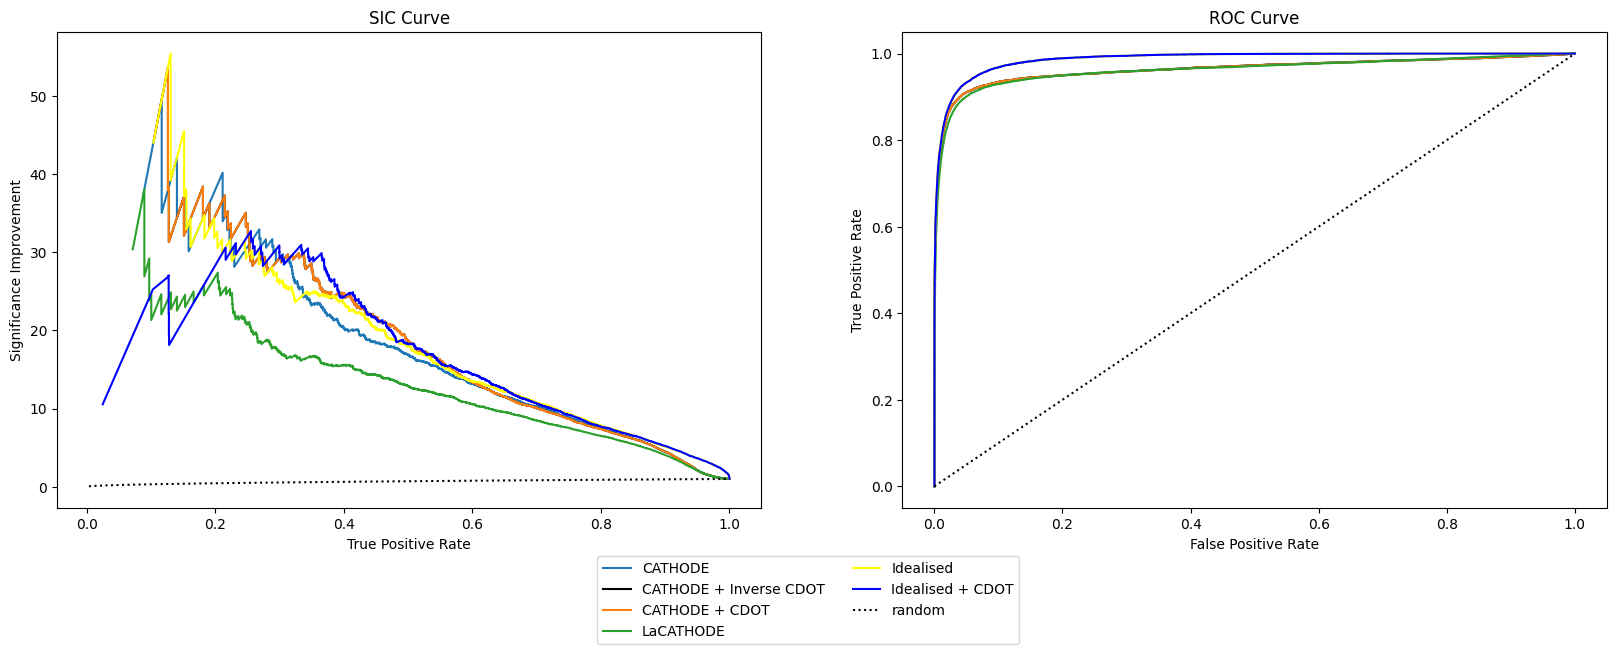

In [30]:
fig, axs = plt.subplots(1,2, figsize = (20,7))

axs[0].plot(h_tpr, h_sic, label="CATHODE")
axs[0].plot(inv_trans_h_tpr, inv_trans_h_sic, label="CATHODE + Inverse CDOT", color = "black")
axs[0].plot(trans_h_tpr, trans_h_sic, label="CATHODE + CDOT")

axs[0].plot(la_h_tpr, la_h_sic, label="LaCATHODE")
axs[0].plot(ideal_h_tpr, ideal_h_sic, label = "Idealised", color = "yellow")
axs[0].plot(trans_ideal_h_tpr, trans_ideal_h_sic, label = "Idealised + CDOT", color = "blue")
axs[0].plot(random_tpr, random_sic, "k:", label="random")
axs[0].set_xlabel("True Positive Rate")
axs[0].set_ylabel("Significance Improvement")
axs[0].set_title("SIC Curve")


axs[1].plot(h_fpr, h_tpr, label="CATHODE")
axs[1].plot(inv_trans_h_fpr, inv_trans_h_tpr, label="CATHODE + Inverse CDOT", color = "black")
axs[1].plot(trans_h_fpr, trans_h_tpr, label="CATHODE + CDOT")

axs[1].plot(la_h_fpr, la_h_tpr, label="LaCATHODE")
axs[1].plot(ideal_h_fpr, ideal_h_tpr, label = "Idealised", color = "yellow")
axs[1].plot(trans_ideal_h_fpr, trans_ideal_h_tpr, label = "Idealised + CDOT", color = "blue")
axs[1].plot(random_tpr, random_tpr, "k:", label="random")
axs[1].set_xlabel("False Positive Rate")
axs[1].set_ylabel("True Positive Rate")
axs[1].set_title("ROC Curve")

h, l = axs[0].get_legend_handles_labels()     # Avoid repeats of legend, labels from 1st plot

fig.legend(h, l, loc="lower center", ncol = 2)
fig.subplots_adjust(bottom = 0.2)

plt.show()

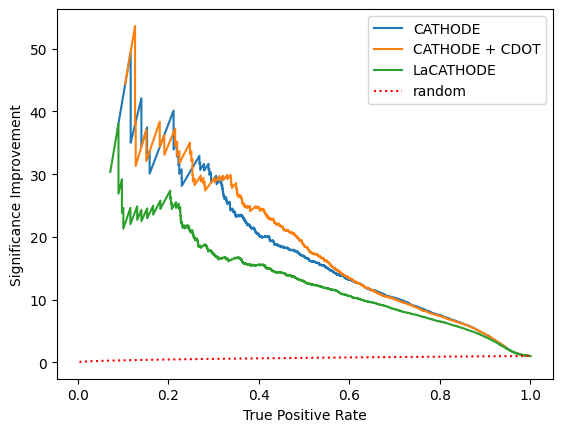

In [31]:

with np.errstate(divide='ignore', invalid='ignore'):
    # Classifier Outputs (Pre-CDOT)
    h_fpr, h_tpr, _ = roc_curve(test_df["signal"], test_df["h"])
    h_sic = h_tpr / np.sqrt(h_fpr)

    # Transformed Classifier outputs (Post-CDOT)
    trans_h_fpr, trans_h_tpr, _ = roc_curve(test_df["signal"], test_df["trans_h"])
    trans_h_sic = trans_h_tpr / np.sqrt(trans_h_fpr)

    # LaCATHODE classifier outputs
    la_h_fpr, la_h_tpr, _ = roc_curve(test_df[~np.isnan(test_df["la_h"])]["signal"], test_df[~np.isnan(test_df["la_h"])]["la_h"])
    la_h_sic = la_h_tpr / np.sqrt(la_h_fpr)

    # Random Line
    random_tpr = np.linspace(0, 1, 300)
    random_sic = random_tpr / np.sqrt(random_tpr)

plt.plot(h_tpr, h_sic, label="CATHODE")
plt.plot(trans_h_tpr, trans_h_sic, label="CATHODE + CDOT")
plt.plot(la_h_tpr, la_h_sic, label="LaCATHODE")
plt.plot(random_tpr, random_sic, "r:", label="random")
plt.xlabel("True Positive Rate")
plt.ylabel("Significance Improvement")
plt.legend(loc="upper right")
plt.show()

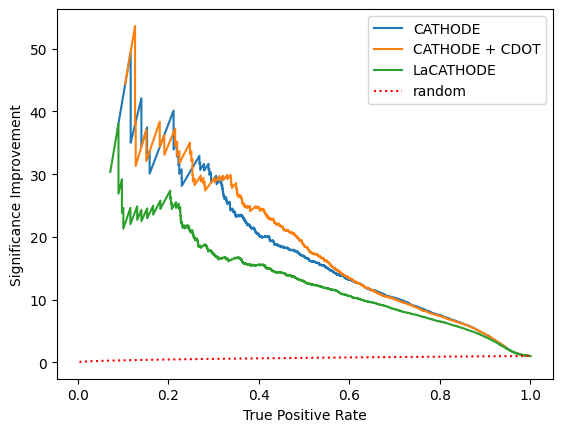

In [32]:

with np.errstate(divide='ignore', invalid='ignore'):
    # Classifier Outputs (Pre-CDOT)
    h_fpr, h_tpr, _ = roc_curve(test_df["signal"], test_df["h"])
    h_sic = h_tpr / np.sqrt(h_fpr)

    # Transformed Classifier outputs (Post-CDOT)
    trans_h_fpr, trans_h_tpr, _ = roc_curve(test_df["signal"], test_df["trans_h"])
    trans_h_sic = trans_h_tpr / np.sqrt(trans_h_fpr)

    # LaCATHODE classifier outputs
    la_h_fpr, la_h_tpr, _ = roc_curve(test_df[~np.isnan(test_df["la_h"])]["signal"], test_df[~np.isnan(test_df["la_h"])]["la_h"])
    la_h_sic = la_h_tpr / np.sqrt(la_h_fpr)

    # Random Line
    random_tpr = np.linspace(0, 1, 300)
    random_sic = random_tpr / np.sqrt(random_tpr)

plt.plot(h_tpr, h_sic, label="CATHODE")
plt.plot(trans_h_tpr, trans_h_sic, label="CATHODE + CDOT")
plt.plot(la_h_tpr, la_h_sic, label="LaCATHODE")
plt.plot(random_tpr, random_sic, "r:", label="random")
plt.xlabel("True Positive Rate")
plt.ylabel("Significance Improvement")
plt.legend(loc="upper right")
plt.show()

# Plot 8
# SIC Curve (After CDOT transformation)